# Facility-Level Weather Sensitivity — GHGRP × ERA5, 2023
## Next-step analysis · Harvard D³ Institute · Suhail Mahmud, PhD

**Motivation.** The national-level analysis found that atmospheric variables explain almost none of the year-to-year variation in U.S. industrial emissions. But national aggregation can *hide* a real local signal: if weather sensitivity exists, it should appear at the facility level, within the most weather-exposed sectors. This notebook tests that by joining each 2023 GHGRP facility's coordinates to its ERA5 grid cell and examining the **power** and **oil & gas** sectors specifically.

**Scope and honest caveat.** With a single year (2023), every facility has *one* emissions value and *one* local climate value, so this is a **cross-sectional** analysis: do facilities in hotter / drier locations emit more? It is **not** a within-facility *sensitivity* test (that needs the multi-year panel — the natural follow-up). Cross-sectional results are confounded by *why* facilities sit where they do: oil & gas clusters in the hot, arid Permian Basin for geological reasons, not because heat causes emissions. We report associations and quantify how much variance climate explains, while flagging this confounding throughout.

**Data**
- **EPA GHGRP 2023** facility file (`ghgp_data_2023.xlsx`, "Direct Point Emitters"): per-facility emissions, sector, latitude, longitude.
- **ERA5 2023** (from the uploaded GRIB): per-grid-cell annual and summer temperature, VPD, RH, wind, surface pressure.

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

GRIB_PATH = "era5_conus.grib"
EPA_2023  = "ghgp_data_2023.xlsx"   # single-year file: richest facility schema
np.random.seed(42)
print("Ready.")

Ready.


## 2. Load 2023 facilities (coordinates + sector + emissions)

In [2]:
fac = pd.read_excel(EPA_2023, sheet_name="Direct Point Emitters", header=3)
fac = fac.rename(columns={
    "Total reported direct emissions":"emis_co2e",
    "Industry Type (sectors)":"sectors",
    "Latitude":"lat", "Longitude":"lon"})
for c in ["emis_co2e","lat","lon"]:
    fac[c] = pd.to_numeric(fac[c], errors="coerce")
fac["primary_sector"] = fac["sectors"].astype(str).str.split(",").str[0].str.strip()

# CONUS facilities with valid coords and positive emissions
fac = fac[fac.lat.between(24,50) & fac.lon.between(-125,-66) & (fac.emis_co2e > 0)].copy()
print(f"CONUS facilities (2023): {len(fac):,}")
fac.groupby("primary_sector")["emis_co2e"].agg(["count","sum"]).sort_values("sum", ascending=False).head(8)

CONUS facilities (2023): 6,334


,count,sum
primary_sector,,
Power Plants,1242,1.415801e+09
Chemicals,454,2.765018e+08
Other,1218,1.351274e+08
Minerals,381,1.096013e+08
Petroleum and Natural Gas Systems,1160,1.032609e+08
Waste,1172,9.040908e+07
Metals,295,8.413874e+07
Petroleum Product Suppliers,71,6.785679e+07


## 3. Build per-cell ERA5 2023 grids
Unlike the national analysis (which area-averaged everything), here we keep the **full spatial grid** so each facility gets its *local* climate.

In [3]:
ds = xr.open_dataset(GRIB_PATH, engine="cfgrib")
ds23 = ds.sel(time=ds.time.dt.year == 2023)

def es_kpa(t):   # Tetens saturation vapor pressure (kPa)
    return 0.6108 * np.exp(17.27 * t / (t + 237.3))

t2m = ds23["t2m"] - 273.15
d2m = ds23["d2m"] - 273.15
vpd = (es_kpa(t2m) - es_kpa(d2m)).clip(min=0)
rh  = 100 * (es_kpa(d2m) / es_kpa(t2m))
wind = np.sqrt(ds23["u10"]**2 + ds23["v10"]**2)

grid = xr.Dataset({
    "t2m_c":   t2m.mean("time"),
    "vpd_kpa": vpd.mean("time"),
    "rh_pct":  rh.mean("time"),
    "wind_ms": wind.mean("time"),
    "sp_hpa":  ds23["sp"].mean("time")/100,
})
jja = ds23.sel(time=ds23.time.dt.month.isin([6,7,8]))
tj, dj = jja["t2m"]-273.15, jja["d2m"]-273.15
grid["t2m_jja_c"]   = tj.mean("time")
grid["vpd_jja_kpa"] = (es_kpa(tj) - es_kpa(dj)).clip(min=0).mean("time")
print("ERA5 2023 grid:", dict(grid.dims))

Ignoring index file 'era5_conus.grib.5b7b6.idx' incompatible with GRIB file


skipping variable: paramId==228 shortName='tp'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1262304000, 1264982400, 1267401600, 1270080000, 1272672000,
       1275350400, 1277942400, 1280620800, 1283299200, 1285891200,
       1288569600, 1291161600, 1293840000, 1296518400, 1298937600,
       1301616000, 1304208000, 1306886400, 1309478400, 1312156800,
       1314835200, 1317427200, 1320105600, 1322697600, 1325376000,
       1328054400, 1330560000, 1333238400, 1335830400, 1338508800,
       1341100800, 1343779200, 1346457600, 1349049600, 1351728000,
       1354320000, 1356998400, 1359676800, 1362096000, 13

ERA5 2023 grid: {'latitude': 101, 'longitude': 233}


## 4. Spatial join — nearest ERA5 cell to each facility
ERA5 is on a 0.25° grid (~25 km). We snap each facility to its nearest cell. (A future refinement could bilinearly interpolate, but at 0.25° the nearest-cell error is small relative to the facility footprint.)

In [4]:
lats, lons = grid.latitude.values, grid.longitude.values
def nearest_ij(lat, lon):
    return np.abs(lats-lat).argmin(), np.abs(lons-lon).argmin()

for v in ["t2m_c","vpd_kpa","rh_pct","wind_ms","sp_hpa","t2m_jja_c","vpd_jja_kpa"]:
    arr = grid[v].values
    fac[v] = [arr[nearest_ij(la, lo)] for la, lo in zip(fac.lat, fac.lon)]

fac["log_emis"] = np.log10(fac["emis_co2e"])   # emissions are highly right-skewed
print(f"Joined climate to {len(fac):,} facilities.")
fac[["Facility Name","State","primary_sector","emis_co2e","t2m_jja_c","vpd_jja_kpa"]].head()

Joined climate to 6,334 facilities.


,Facility Name,State,primary_sector,emis_co2e,t2m_jja_c,vpd_jja_kpa
0,30-30 Gas Plant,TX,Injection of CO2,44170.546,28.629953,2.607854
1,50 Buttes Gas Plant,WY,Petroleum and Natural Gas Systems,61389.032,19.250397,1.037925
2,AJAX PLANT,TX,Petroleum and Natural Gas Systems,38738.508,26.252350,1.521685
3,AKER PLANT,TX,Petroleum and Natural Gas Systems,39758.102,30.993235,2.023656
4,ALLIANCE COMPRESSOR STATION,TX,Petroleum and Natural Gas Systems,48988.056,31.208731,2.311850


## 5. Map: facilities joined to grid, power & oil/gas highlighted

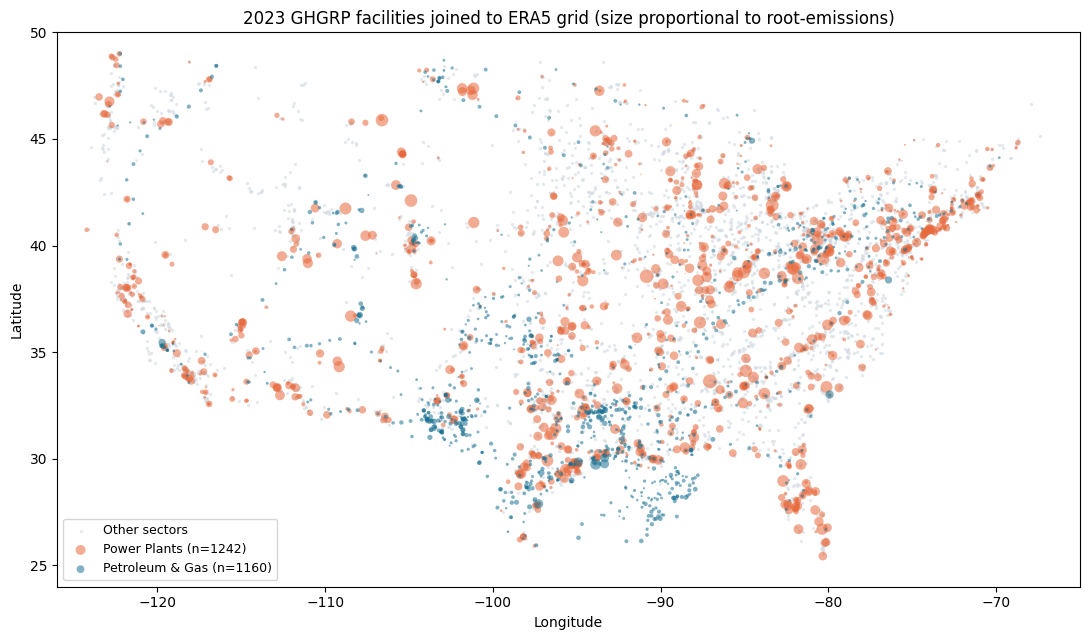

In [5]:
fig, ax = plt.subplots(figsize=(11,6.5))
DEEP,TEAL,MID,ACCENT,GREY = "#065A82","#1C7293","#21295C","#E8693C","#8896A6"
focus = {"Power Plants":ACCENT, "Petroleum and Natural Gas Systems":TEAL}
other = fac[~fac.primary_sector.isin(focus)]
ax.scatter(other.lon, other.lat, s=2, c="#d5dce3", alpha=0.5, label="Other sectors")
for sec,col in focus.items():
    s = fac[fac.primary_sector==sec]
    ax.scatter(s.lon, s.lat, s=np.sqrt(s.emis_co2e)/40, c=col, alpha=0.55, edgecolors="none",
               label=f'{sec.replace(" and Natural Gas Systems"," & Gas")} (n={len(s)})')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("2023 GHGRP facilities joined to ERA5 grid (size proportional to root-emissions)")
ax.legend(loc="lower left", fontsize=9); ax.set_xlim(-126,-65); ax.set_ylim(24,50)
plt.tight_layout(); plt.show()

The map already hints at the confounding: the dense teal oil & gas cluster in west Texas / New Mexico is the **Permian Basin**, which is hot and dry for geological-economic reasons. Any positive "VPD → emissions" association in that sector partly reflects *where the oil is*, not a causal weather effect.

## 6. Within-sector cross-sectional correlations

In [6]:
def sector_corr(sec):
    s = fac[fac.primary_sector==sec]
    rows=[]
    for v,lbl in [("t2m_c","Annual temp"),("t2m_jja_c","Summer temp"),("vpd_jja_kpa","Summer VPD"),
                  ("rh_pct","Rel humidity"),("wind_ms","Wind"),("sp_hpa","Pressure")]:
        r,p = pearsonr(s[v], s["log_emis"])
        rows.append({"variable":lbl,"r":round(r,3),"p":round(p,4),"sig_05":p<0.05})
    out = pd.DataFrame(rows)
    print(f"\n{sec}  (n={len(s)}, total={s.emis_co2e.sum()/1e6:.0f} MMt CO2e)")
    return out

display(sector_corr("Power Plants"))
display(sector_corr("Petroleum and Natural Gas Systems"))


Power Plants  (n=1242, total=1416 MMt CO2e)


,variable,r,p,sig_05
0,Annual temp,0.152,0.0000,True
1,Summer temp,0.166,0.0000,True
2,Summer VPD,0.068,0.0173,True
3,Rel humidity,-0.025,0.3841,False
4,Wind,-0.030,0.2844,False
5,Pressure,-0.036,0.2001,False



Petroleum and Natural Gas Systems  (n=1160, total=103 MMt CO2e)


,variable,r,p,sig_05
0,Annual temp,0.047,0.1119,False
1,Summer temp,0.064,0.0298,True
2,Summer VPD,0.082,0.0051,True
3,Rel humidity,-0.036,0.2174,False
4,Wind,0.065,0.0273,True
5,Pressure,-0.058,0.0476,True


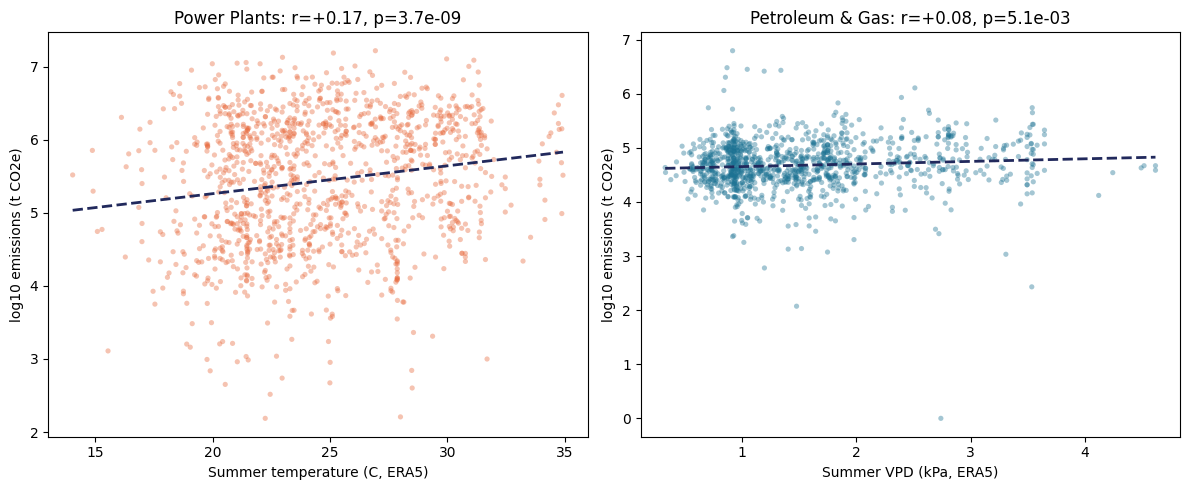

In [7]:
# Visual: two scatter panels
fig, axs = plt.subplots(1,2, figsize=(12,5))
for ax,(sec,v,xl,col) in zip(axs,[
        ("Power Plants","t2m_jja_c","Summer temperature (C, ERA5)",ACCENT),
        ("Petroleum and Natural Gas Systems","vpd_jja_kpa","Summer VPD (kPa, ERA5)",TEAL)]):
    s = fac[fac.primary_sector==sec]
    ax.scatter(s[v], s["log_emis"], s=14, c=col, alpha=0.4, edgecolors="none")
    b = np.polyfit(s[v], s["log_emis"], 1); xr_ = np.linspace(s[v].min(), s[v].max(), 100)
    ax.plot(xr_, np.polyval(b, xr_), "--", color=MID, lw=2)
    r,p = pearsonr(s[v], s["log_emis"])
    ax.set_xlabel(xl); ax.set_ylabel("log10 emissions (t CO2e)")
    ax.set_title(f'{sec.replace(" and Natural Gas Systems"," & Gas")}: r={r:+.2f}, p={p:.1e}')
plt.tight_layout(); plt.show()

**Reading the correlations.** Several are statistically significant at p<0.05 — a contrast with the national analysis where nothing was. But note the **effect sizes are tiny** (|r| ≈ 0.07–0.17). With n>1,000 facilities, even a trivial association clears the significance threshold. Significance ≠ importance: the next cell quantifies how much variance climate actually explains.

## 7. Regression with controls — how much does climate actually explain?

In [8]:
clim = ["t2m_jja_c","vpd_jja_kpa","rh_pct","wind_ms","sp_hpa"]
for sec in ["Power Plants","Petroleum and Natural Gas Systems"]:
    s = fac[fac.primary_sector==sec]
    X = StandardScaler().fit_transform(s[clim].values)
    m = sm.OLS(s["log_emis"].values, sm.add_constant(X)).fit()
    print(f"\n{sec} (n={len(s)})")
    print(f"  Climate-only R2 = {m.rsquared:.4f}  ->  climate explains {m.rsquared*100:.1f}% of "
          f"log-emission variance ({100-m.rsquared*100:.1f}% is NOT climate)")
    for n,c,p in zip(["const"]+clim, m.params, m.pvalues):
        print(f"    {n:14s} beta={c:+.3f}  p={p:.4f} {'**' if p<0.05 else ''}")


Power Plants (n=1242)
  Climate-only R2 = 0.0572  ->  climate explains 5.7% of log-emission variance (94.3% is NOT climate)
    const          beta=+5.440  p=0.0000 **
    t2m_jja_c      beta=+0.321  p=0.0000 **
    vpd_jja_kpa    beta=-0.113  p=0.1922 
    rh_pct         beta=+0.132  p=0.0883 
    wind_ms        beta=-0.031  p=0.2265 
    sp_hpa         beta=-0.210  p=0.0000 **

Petroleum and Natural Gas Systems (n=1160)
  Climate-only R2 = 0.0268  ->  climate explains 2.7% of log-emission variance (97.3% is NOT climate)
    const          beta=+4.680  p=0.0000 **
    t2m_jja_c      beta=+0.008  p=0.8094 
    vpd_jja_kpa    beta=+0.153  p=0.0028 **
    rh_pct         beta=+0.184  p=0.0000 **
    wind_ms        beta=+0.000  p=0.9891 
    sp_hpa         beta=-0.101  p=0.0003 **


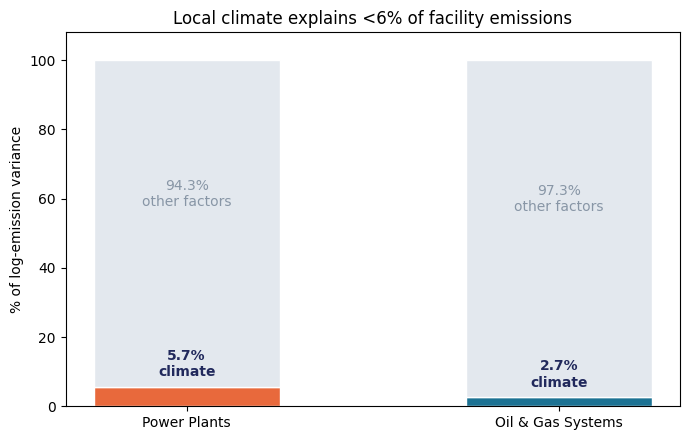

In [9]:
# Variance-explained visual
fig, ax = plt.subplots(figsize=(7,4.5))
labs=["Power Plants","Oil & Gas Systems"]; r2=[5.7,2.7]
ax.bar(labs, r2, color=[ACCENT,TEAL], width=0.5, edgecolor="white")
ax.bar(labs, [100-x for x in r2], bottom=r2, color="#e3e8ee", width=0.5, edgecolor="white")
for i,v in enumerate(r2):
    ax.text(i, v+3, f"{v:.1f}%\nclimate", ha="center", fontweight="bold", color=MID)
    ax.text(i, v+(100-v)/2+5, f"{100-v:.1f}%\nother factors", ha="center", color=GREY)
ax.set_ylabel("% of log-emission variance"); ax.set_ylim(0,108)
ax.set_title("Local climate explains <6% of facility emissions")
plt.tight_layout(); plt.show()

## 8. Findings

1. **A weak local climate signal does exist at the facility level.** For power plants, facilities in warmer locations have modestly higher emissions (summer-temp r = +0.17, p < 0.0001) — plausibly cooling-driven generation demand. For oil & gas, summer VPD and humidity are significant (p < 0.01).

2. **But the effect is small.** Local climate explains only **5.7%** of power-plant log-emission variance and **2.7%** for oil & gas. Over 94% is driven by facility scale, technology, fuel, capacity factor, and economics — not weather.

3. **Significance is inflated by sample size.** With >1,000 facilities per sector, |r| ≈ 0.1 reaches p < 0.05 easily. The honest read is "real but minor," not "important driver."

4. **Cross-sectional confounding is severe.** The oil & gas VPD association largely reflects the Permian Basin being both arid *and* a production hub — geography, not causation. The map in Section 5 makes this visible.

**Bottom line.** Going from national to facility level *surfaces* a local climate signal that national averaging masked — but quantifying it shows it remains a minor factor. This is consistent with, and strengthens, the project's central finding: U.S. industrial emissions are governed by structure (fuel, technology, scale), not weather.

## 9. Next step — the multi-year panel (true sensitivity test)

The clean way to remove the spatial confounding is a **facility-year panel**: stack 2010–2023, and use **facility fixed effects** so each facility is compared *to itself* across years with different weather. Specification:

`log(emissions)_{i,t} = α_i + β·climate_{i,t} + year_t + ε_{i,t}`

The fixed effect α_i absorbs everything time-invariant about facility *i* (its size, technology, and why it's located where it is), so β estimates genuine weather *sensitivity*. The per-year facility files (2010–2023) and the monthly ERA5 grid already in hand are sufficient to build this — the recommended follow-up.